# Semiconductor relative-price shocks
## Baseline empirical study, 2015–2025

> **Bottom line:** Extreme company-versus-peer shocks show a small amount of average gap closure over the next one to five trading days, but the estimates are imprecise, the typical event is close to zero, and the pattern disappears by day 10. This baseline is therefore a **weak descriptive result / practical null**, not evidence of a robust anomaly or causal information diffusion.

**What the data say**

- **242 shocks** were detected: 140 positive and 102 negative.
- **Day 1:** mean convergence **+0.54%** (95% CI **−0.16% to +1.24%**); median **+0.24%**; 54.0% positive.
- **Day 5:** mean convergence **+0.38%** (95% CI **−0.31% to +1.06%**); median **+0.10%**; 51.4% positive.
- The five-day mean decomposes into **+0.22% peer catch-up** and **+0.16% initiator reversal**, but both component confidence intervals include zero and both component medians are slightly negative.
- **Day 10:** mean convergence is **−0.15%**. There is no persistent all-event convergence pattern.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

from price_diffusion.baseline import CONFIG_PATH, run_baseline
from price_diffusion.config import load_config

config = load_config(CONFIG_PATH)
artifacts = run_baseline()

def show_table(frame, caption, formatters=None):
    html = frame.to_html(index=False, border=0, escape=False, formatters=formatters or {})
    display(HTML(f"<h4>{caption}</h4>{html}"))

display(Markdown(f"*Reproduced from `{CONFIG_PATH.relative_to(Path.cwd())}` and the Stage 11D datasets.*"))

*Reproduced from `configs/final_baseline.yaml` and the Stage 11D datasets.*

## Research question and frozen design

After an extreme semiconductor peer-relative price shock, does the gap close because peers catch up, the initiating company reverses, both occur, or neither occurs?

A positive reported outcome always means convergence, regardless of whether the original shock was positive or negative. Day 0 selects the event; post-event outcomes begin at t+1. Parameters and peer definitions are not changed after observing the results.

In [2]:
design = pd.DataFrame([
    ('Sample', f"{config['date_range']['start']} through {config['date_range']['end']}"),
    ('Universe', '36 point-in-time eligible core securities from 54 reviewed names'),
    ('Peers', 'Equal-weight, leave-one-out securities in the same reviewed economic subsector'),
    ('Event', 'Absolute peer-relative abnormal return > max(5%, 3 × trailing volatility)'),
    ('History / peers', '60 prior valid observations and at least 3 peers'),
    ('Horizons', '1 and 5 trading days primary; 3 and 10 days secondary'),
    ('Inference', '95% analytical confidence intervals clustered by initiating firm'),
    ('Interpretation', 'Conditional descriptive event study; not causal and not a trading backtest'),
], columns=['Design choice', 'Frozen specification'])
show_table(design, 'Pre-specified baseline design')

Design choice,Frozen specification
Sample,2015-01-01 through 2025-12-31
Universe,36 point-in-time eligible core securities from 54 reviewed names
Peers,"Equal-weight, leave-one-out securities in the same reviewed economic subsector"
Event,"Absolute peer-relative abnormal return > max(5%, 3 × trailing volatility)"
History / peers,60 prior valid observations and at least 3 peers
Horizons,1 and 5 trading days primary; 3 and 10 days secondary
Inference,95% analytical confidence intervals clustered by initiating firm
Interpretation,Conditional descriptive event study; not causal and not a trading backtest


## Sample

The baseline contains 36 core securities that are eligible at some point during the sample. The 18 extension-tier names remain in metadata but are outside this baseline. CXMT, Cerebras, and Qnity are shown separately because they have fewer than 252 observations; CXMT and Cerebras begin after the frozen sample ends.

In [3]:
sample = pd.DataFrame({
    'Measure': ['Reviewed securities', 'Baseline-eligible securities', 'Excluded extension-tier securities', 'Detected events', 'Positive shocks', 'Negative shocks'],
    'Count': [54, 36, 18, 242, 140, 102],
})
show_table(sample, 'Baseline sample at a glance')

short = artifacts.tables['short_history_exclusions'][['ticker', 'first_trading_date', 'number_of_observations']].copy()
short.columns = ['Security', 'First observed date', 'Total observations through 2026-08-21']
show_table(short, 'Short-history securities retained in metadata')

Measure,Count
Reviewed securities,54
Baseline-eligible securities,36
Excluded extension-tier securities,18
Detected events,242
Positive shocks,140
Negative shocks,102


Security,First observed date,Total observations through 2026-08-21
688825.SS,2026-07-27,20
CBRS,2026-05-14,69
Q,2025-10-27,206


## Main result: small point estimates, wide uncertainty

The average event closes by roughly 0.2%–0.5% during days 1–5, but every all-event 95% confidence interval crosses zero. Medians and positive shares are close to zero and 50%, respectively.

In [4]:
mechanism = artifacts.tables['mechanism_decomposition'].copy()
distribution = artifacts.tables['distribution_statistics']
positive_share = distribution[(distribution['direction'] == 'all') & (distribution['outcome'] == 'convergence')][['horizon', 'proportion_positive']]
results = mechanism.merge(positive_share, on='horizon', validate='one_to_one')
results = pd.DataFrame({
    'Horizon': results['horizon'].astype(int),
    'Complete events': results['valid_events'].astype(int),
    'Mean convergence': results['convergence_mean'] * 100,
    '95% CI': results.apply(lambda r: f"{100*r['convergence_ci_lower']:+.2f}% to {100*r['convergence_ci_upper']:+.2f}%", axis=1),
    'Median convergence': results['convergence_median'] * 100,
    'Positive outcomes': results['proportion_positive'] * 100,
    'Peer catch-up': results['peer_catchup_mean'] * 100,
    'Initiator reversal': results['initiator_reversal_mean'] * 100,
})
show_table(results, 'Sign-normalized post-event outcomes', {
    'Mean convergence': lambda x: f'{x:+.2f}%',
    'Median convergence': lambda x: f'{x:+.2f}%',
    'Positive outcomes': lambda x: f'{x:.1f}%',
    'Peer catch-up': lambda x: f'{x:+.2f}%',
    'Initiator reversal': lambda x: f'{x:+.2f}%',
})

Horizon,Complete events,Mean convergence,95% CI,Median convergence,Positive outcomes,Peer catch-up,Initiator reversal
1,226,+0.54%,-0.16% to +1.24%,+0.24%,54.0%,+0.26%,+0.28%
3,196,+0.21%,-0.52% to +0.93%,+0.12%,51.5%,+0.18%,+0.03%
5,173,+0.38%,-0.31% to +1.06%,+0.10%,51.4%,+0.22%,+0.16%
10,114,-0.15%,-1.52% to +1.23%,-0.46%,48.2%,+0.26%,-0.41%


### How to read this

- **One day:** The +0.54% mean is the strongest all-event estimate, but its interval includes zero (−0.16% to +1.24%). The distribution is right-skewed, so a small number of large convergence events lift the mean above the +0.24% median.
- **Five days:** The +0.38% mean is split between peers moving in the shock direction (+0.22%) and initiators moving back (+0.16%). Yet the typical component is not positive: both medians are about −0.09%.
- **Ten days:** Mean convergence turns negative (−0.15%), mainly because initiator reversal changes sign. The short-run point estimate is not persistent.

This is why an honest summary is **weak short-run convergence in the mean, but no robust or persistent convergence across the distribution**.

## Event-time path

The event-day jump is visible as a large signed initiator move relative to peers. After day 0, the gap narrows only modestly before widening again later in the window. The plotted paths cumulate from t=−5; an upward movement in the green peer-minus-initiator line after day 0 represents convergence.

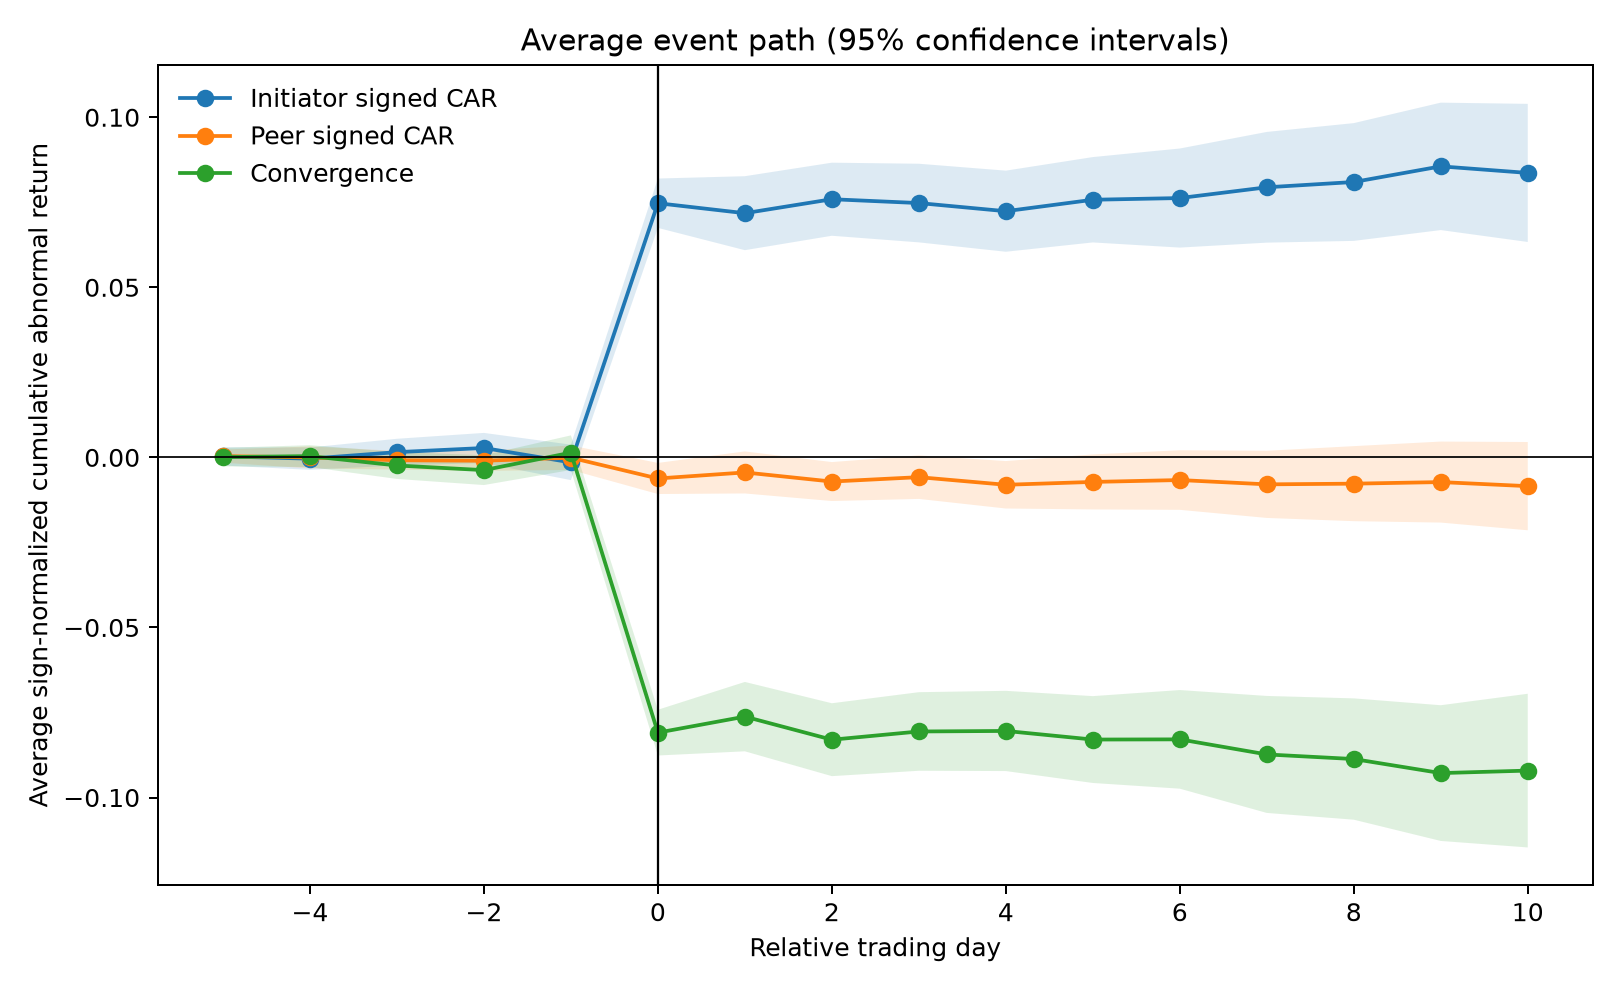

In [5]:
display(Image(filename='outputs/baseline/figures/event_path.png', width=950))

## Which side moves?

Both mechanisms have small positive means through day 5. Neither is estimated precisely. By day 10 the initiator component is negative, offsetting the still-small peer component.

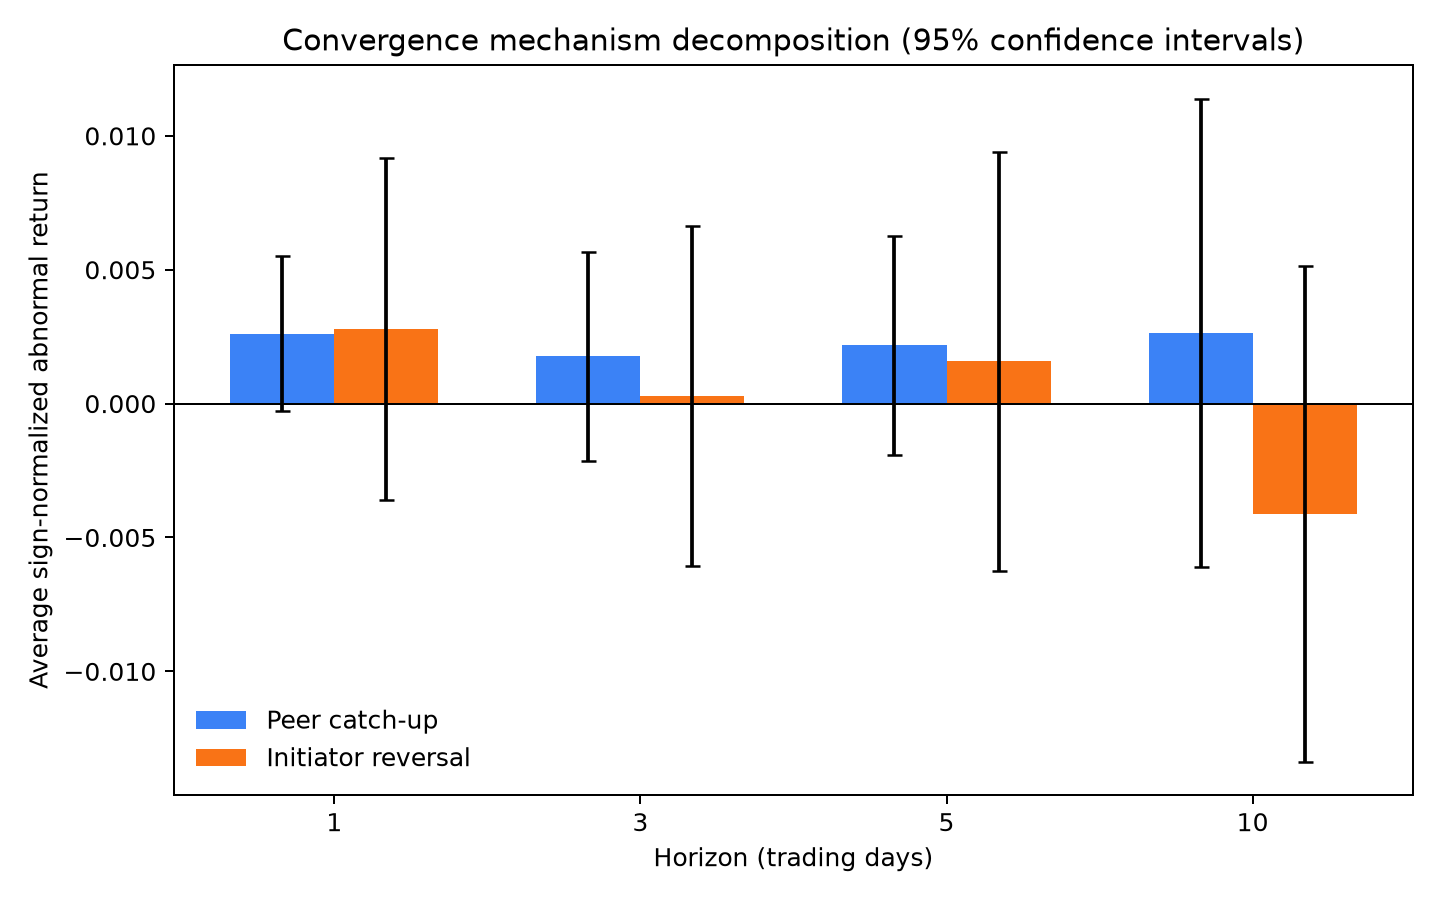

In [6]:
display(Image(filename='outputs/baseline/figures/convergence_components.png', width=900))

## The five-day distributions

The averages conceal broad, roughly zero-centered distributions. Positive shocks have a somewhat more positive five-day convergence mean; negative shocks are essentially flat. This direction split is descriptive and was not used to alter the baseline.

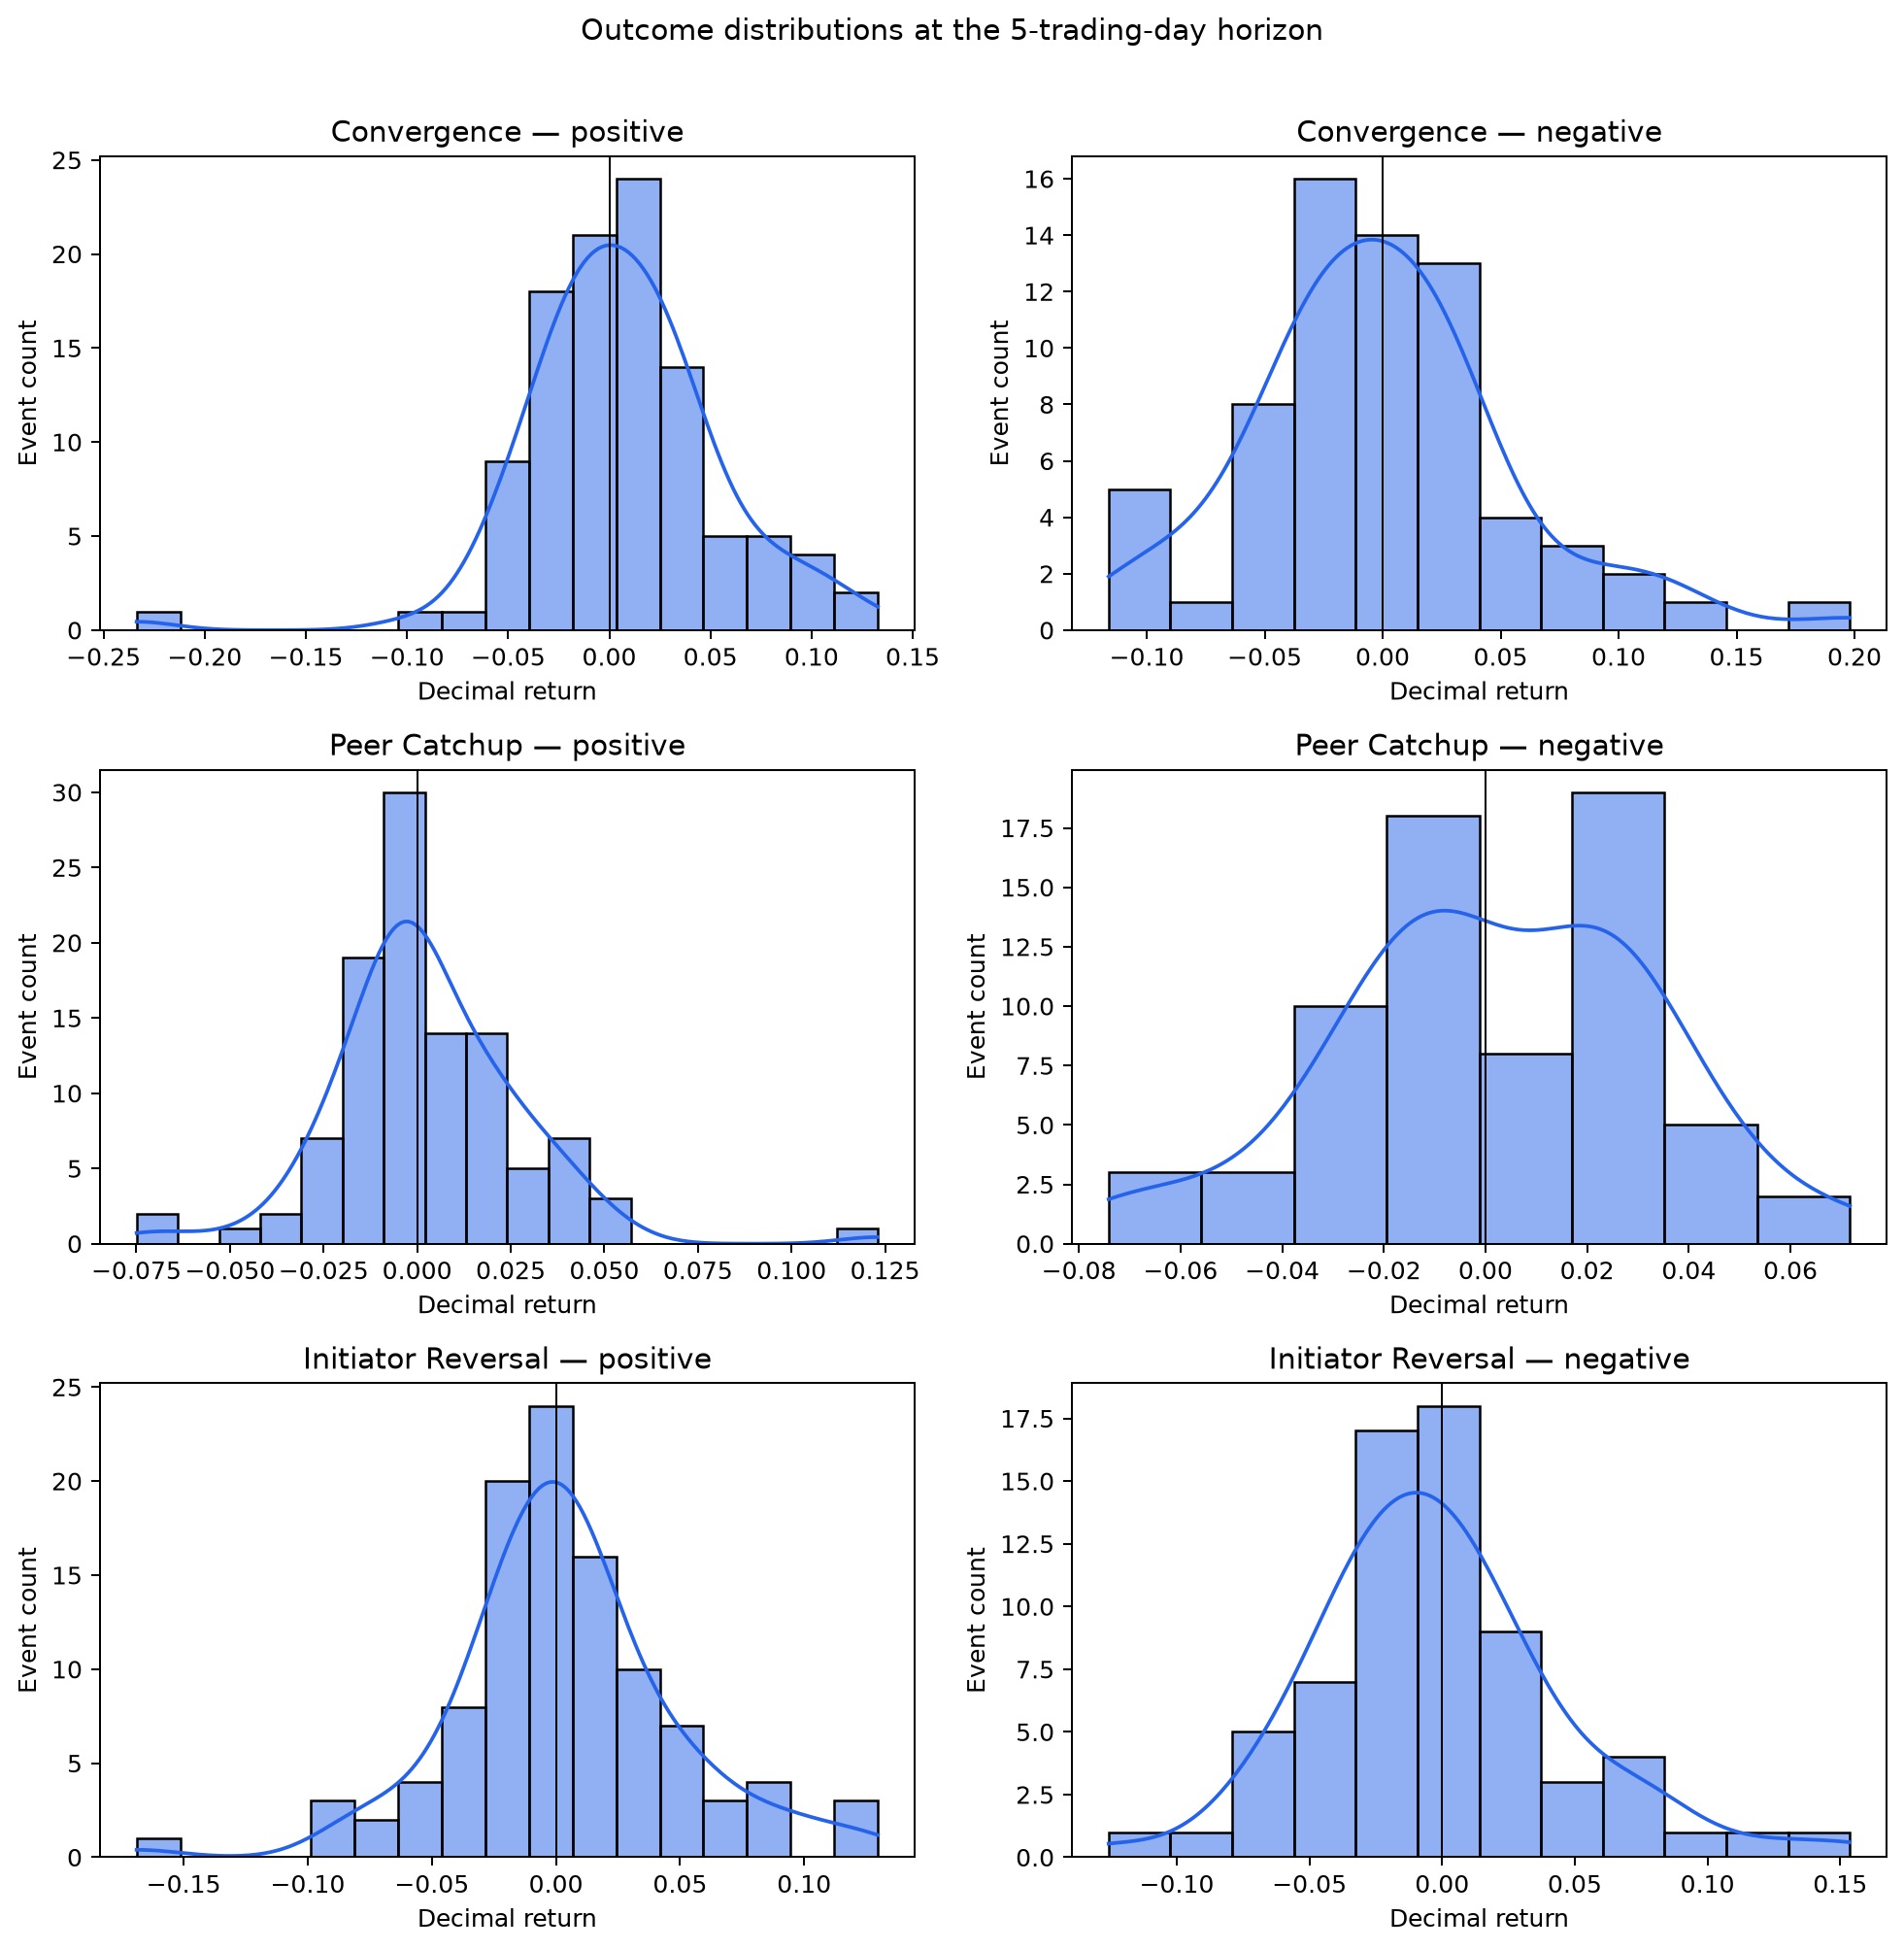

In [7]:
display(Image(filename='outputs/baseline/figures/outcome_distributions.png', width=950))

In [8]:
direction = artifacts.tables['outcome_summary']
direction = direction[(direction['horizon'] == 5) & (direction['outcome'] == 'convergence') & (direction['direction'] != 'all')].copy()
direction_table = pd.DataFrame({
    'Shock direction': direction['direction'].str.title(),
    'Complete events': direction['sample_size'].astype(int),
    'Mean convergence': direction['mean'] * 100,
    '95% CI': direction.apply(lambda r: f"{100*r['ci_lower']:+.2f}% to {100*r['ci_upper']:+.2f}%", axis=1),
    'Median convergence': direction['median'] * 100,
    'Positive outcomes': direction['proportion_positive'] * 100,
})
show_table(direction_table, 'Five-day convergence by original shock direction', {
    'Mean convergence': lambda x: f'{x:+.2f}%',
    'Median convergence': lambda x: f'{x:+.2f}%',
    'Positive outcomes': lambda x: f'{x:.1f}%',
})

Shock direction,Complete events,Mean convergence,95% CI,Median convergence,Positive outcomes
Negative,68,-0.01%,-1.22% to +1.20%,-0.24%,48.5%
Positive,105,+0.63%,-0.35% to +1.61%,+0.45%,53.3%


## Diagnostics that materially affect interpretation

Horizon completeness falls rapidly because a frozen peer portfolio is valid only when the initiator and every event-date peer have observations throughout the window. International exchange holidays are the main source of attrition. No company exceeds the pre-defined concentration flag; STMicroelectronics is largest with 24 events (9.9%).

In [9]:
missing = artifacts.tables['horizon_missingness'].copy()
missing.columns = ['Horizon', 'Detected events', 'Complete outcomes', 'Excluded outcomes']
missing['Completion rate'] = 100 * missing['Complete outcomes'] / missing['Detected events']
show_table(missing, 'Outcome completeness by horizon', {'Completion rate': lambda x: f'{x:.1f}%'})

companies = artifacts.tables['company_concentration'][['ticker', 'company_name', 'event_count', 'event_share']].head(8).copy()
companies.columns = ['Ticker', 'Company', 'Events', 'Share of events']
show_table(companies, 'Largest initiating-company event counts', {'Share of events': lambda x: f'{x:.1%}'})

dates = artifacts.tables['date_concentration'].head(9)[['date', 'event_count', 'subsector_count']].copy()
dates.columns = ['Date', 'Events', 'Subsectors represented']
show_table(dates, 'Dates with at least three simultaneous shocks')

Horizon,Detected events,Complete outcomes,Excluded outcomes,Completion rate
1,242,226,16,93.4%
3,242,196,46,81.0%
5,242,173,69,71.5%
10,242,114,128,47.1%


Ticker,Company,Events,Share of events
STM,STMicroelectronics N.V.,24,9.9%
MPWR,Monolithic Power Systems Inc.,21,8.7%
ON,onsemi,21,8.7%
AMAT,Applied Materials Inc.,18,7.4%
KLAC,KLA Corporation,16,6.6%
NXPI,NXP Semiconductors N.V.,16,6.6%
LRCX,Lam Research Corporation,15,6.2%
MCHP,Microchip Technology Incorporated,15,6.2%


Date,Events,Subsectors represented
2023-05-25,5,3
2024-12-03,5,2
2025-01-27,4,3
2025-04-09,4,1
2020-03-13,3,1
2024-02-05,3,3
2024-05-30,3,1
2024-07-31,3,2
2025-04-07,3,1


## Conclusion

The first frozen baseline does **not** reveal a clear, stable convergence effect. Average gap closure is positive at one and five days, and its point estimate is consistent with a mixture of delayed peer adjustment and initiator reversal. But the evidence is weak: all-event confidence intervals include zero, medians are small, only about half of outcomes converge, component medians are not positive at five days, and the aggregate pattern reverses by day 10.

The defensible finding is therefore:

> **Extreme semiconductor peer-relative shocks are followed by modest short-run convergence in the sample mean, but not by robust or persistent convergence across events.**

This is compatible with delayed peer adjustment or temporary relative-price dislocation in some episodes. It does not identify either mechanism causally, prove information diffusion, or establish a tradable anomaly.

## Important limitations

1. The current reviewed universe is applied retrospectively and is not survivorship-free.
2. International closes are non-synchronous and returns remain in local listing currencies.
3. Yahoo adjusted prices are revisable; corporate-action metadata are incomplete.
4. The equal-weight semiconductor factor includes the focal security. It cancels from the event-day relative signal but affects the reported component levels.
5. Ten-day attrition is severe: only 114 of 242 events have complete frozen-peer outcomes.
6. Confidence intervals condition on selected events. Selection-preserving Stage 10 null models are needed before treating the pattern as unusual.

In [10]:
manifest = pd.read_json('outputs/baseline/manifests/baseline_run_manifest.json', typ='series')
checks = pd.Series(manifest['validations'], name='Passed').rename_axis('Validation').reset_index()
show_table(checks, 'Reproducibility and leakage checks')

Validation,Passed
convergence_identity_valid,True
event_dates_within_frozen_sample,True
no_self_peers,True
point_in_time_eligible_peer_endpoints,True
sign_normalization_valid,True
strictly_trailing_event_volatility,True
